# <center> VAI Store - Modelo Preditivo </center>

---

Este notebook implementa o modelo preditivo. Com base no dataset de features, que foi agregado por CATEGORIA e focado no FATUR_TOTAL, o objetivo é construir um modelo "global" que aprenda os padrões de todas as categorias simultaneamente.

A abordagem segue as dicas do case ("modelar em escala") e as orientações do mentor (focar no faturamento para resolver o problema das unidades de medida). Usaremos um modelo LightGBM e avaliaremos sua performance ("acurácia") usando uma divisão temporal e métricas de erro em Reais (R$).

### **1. Imports e Carregamento de Dados**

Visão Geral: Esta etapa importa as bibliotecas necessárias para a modelagem (pandas, lightgbm, sklearn) e define os caminhos dos arquivos. O dataset feature_engineered_dataset_v2.parquet é carregado. Por ser um arquivo Parquet, a leitura é rápida e os tipos de dados otimizados (como int8 e float32) são preservados, economizando memória e garantindo consistência.

In [24]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')

# Define os caminhos (subindo um nível)
PROCESSED_DATA_PATH = os.path.join('..', 'data', 'processed')
DATA_FILE = os.path.join(PROCESSED_DATA_PATH, 'feature_engineered_dataset.parquet')

print(f"Carregando dataset de: {os.path.abspath(DATA_FILE)}")

# Carrega o dataset
df = pd.read_parquet(DATA_FILE)

# Garante que a data esteja no formato correto (o Parquet preserva isso)
df['DATA_ATEND'] = pd.to_datetime(df['DATA_ATEND'])

print("Dataset carregado com sucesso.")
df.info()

Carregando dataset de: c:\Users\felip\OneDrive\Documentos\GitHub\Grupo6-ProjetoFinal\data\processed\feature_engineered_dataset.parquet
Dataset carregado com sucesso.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4745 entries, 0 to 4744
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   CATEGORIA                    4745 non-null   object        
 1   DATA_ATEND                   4745 non-null   datetime64[ns]
 2   FATUR_TOTAL                  4745 non-null   float32       
 3   DIA_SEMANA                   4745 non-null   int8          
 4   DIA_DO_MES                   4745 non-null   int8          
 5   DIA_DO_ANO                   4745 non-null   int16         
 6   MES                          4745 non-null   int8          
 7   SEMANA_DO_ANO                4745 non-null   int8          
 8   ANO                          4745 non-null   int16         
 9   INICIO_

### **2. Preparação de Features e Alvo**

Visão Geral: O dataset é preparado para o treinamento.

* Alvo (y): Definido como FATUR_TOTAL, nossa métrica de demanda universal (R$).

* Features Categóricas (X): As colunas que representam "etiquetas" (como CATEGORIA, DIA_SEMANA, MES, etc.) são explicitamente convertidas para o dtype 'category'. O LightGBM usa essa informação para tratar essas features de forma otimizada, sem necessidade de One-Hot Encoding.

* Features a Remover: DATA_ATEND (já representada pelas features de calendário) e FATUR_TOTAL (o alvo) são removidas da lista final de features.

In [25]:
# 1. Definir o alvo
TARGET = 'FATUR_TOTAL'

# 2. Definir colunas categóricas
categorical_features = [
    'CATEGORIA',
    'DIA_SEMANA',
    'DIA_DO_MES',
    'DIA_DO_ANO',
    'MES',
    'SEMANA_DO_ANO',
    'ANO',
    'INICIO_MES',
    'FIM_MES',
    'ANTECIPACAO_PASCOA_14D',
    'ANTECIPACAO_NATAL_21D',
    'ANTECIPACAO_ANO_NOVO_7D',
    'EH_FERIADO',
    'INTERACAO_PASCOA_BACALHAU',    
    'INTERACAO_NATAL_BACALHAU',     
    'INTERACAO_ANO_NOVO_BACALHAU'   
]

# 3. Converter colunas categóricas para o dtype 'category'
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype('category')
    else:
        print(f"Aviso: Coluna categórica {col} não encontrada.")


# 4. Definir a lista final de features (X)
features_to_drop = [TARGET, 'DATA_ATEND']
features = [col for col in df.columns if col not in features_to_drop]

print(f"Total de features para o modelo: {len(features)}")
print(f"Alvo: {TARGET}")

# Verifica os dtypes finais
df[features].info()

Total de features para o modelo: 21
Alvo: FATUR_TOTAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4745 entries, 0 to 4744
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   CATEGORIA                    4745 non-null   category
 1   DIA_SEMANA                   4745 non-null   category
 2   DIA_DO_MES                   4745 non-null   category
 3   DIA_DO_ANO                   4745 non-null   category
 4   MES                          4745 non-null   category
 5   SEMANA_DO_ANO                4745 non-null   category
 6   ANO                          4745 non-null   category
 7   INICIO_MES                   4745 non-null   category
 8   FIM_MES                      4745 non-null   category
 9   ANTECIPACAO_PASCOA_14D       4745 non-null   category
 10  ANTECIPACAO_NATAL_21D        4745 non-null   category
 11  ANTECIPACAO_ANO_NOVO_7D      4745 non-null   category
 12  EH_FERIA

### **3. Divisão de Dados (Train/Validation Split)**

Visão Geral: Para avaliar o modelo de forma realista, é crucial usar uma divisão temporal. Uma divisão aleatória (como train_test_split) causaria data leakage, pois o modelo "veria o futuro" para prever o passado. Esta etapa simula a produção: o modelo é treinado com dados até uma data de corte (ex: o penúltimo mês) e é validado no período subsequente (o último mês).

In [26]:
# Define a data de corte (vamos usar o último mês como validação)
data_maxima = df['DATA_ATEND'].max()
data_corte = data_maxima - pd.DateOffset(months=1)

# Divide o DataFrame
df_train = df[df['DATA_ATEND'] < data_corte]
df_val = df[df['DATA_ATEND'] >= data_corte]

# Separa X (features) e y (alvo)
X_train = df_train[features]
y_train = df_train[TARGET]

X_val = df_val[features]
y_val = df_val[TARGET]

print(f"Período de Treino: {df_train['DATA_ATEND'].min().date()} até {df_train['DATA_ATEND'].max().date()}")
print(f"Período de Validação: {df_val['DATA_ATEND'].min().date()} até {df_val['DATA_ATEND'].max().date()}")
print(f"Tamanho do Treino: {len(X_train)} linhas")
print(f"Tamanho da Validação: {len(X_val)} linhas")

Período de Treino: 2024-01-02 até 2024-11-29
Período de Validação: 2024-11-30 até 2024-12-31
Tamanho do Treino: 4329 linhas
Tamanho da Validação: 416 linhas


### **4. Treinamento do Modelo LightGBM**

Visão Geral: Esta etapa treina o modelo LGBMRegressor. Como nosso dataset agora é denso e de alta qualidade (agregado por Categoria), não precisamos de hiperparâmetros complexos; as features farão o trabalho pesado. Usamos eval_set para monitorar a performance no conjunto de validação e early_stopping para evitar overfitting (o modelo para de treinar se o erro de validação não melhorar).

In [27]:
print("Iniciando o treinamento do modelo LightGBM (Otimizado para RMSE)...")

# Define os parâmetros do LGBM
params = {
    # --- MUDANÇA PRINCIPAL AQUI ---
    'objective': 'regression_l2', # 'l2' = RMSE. Força o modelo a focar nos erros grandes (picos)
    # --- FIM DA MUDANÇA ---
    'metric': 'rmse',             # Métrica que queremos acompanhar
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42,
    'boosting_type': 'gbdt',
}

# Inicializa o modelo
model = lgb.LGBMRegressor(**params)

# Treina o modelo
model.fit(
    X_train, 
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse',
    callbacks=[
        lgb.log_evaluation(period=100), 
        lgb.early_stopping(stopping_rounds=100)
    ],
    categorical_feature=categorical_features # Argumento está correto
)

print("Treinamento concluído.")

Iniciando o treinamento do modelo LightGBM (Otimizado para RMSE)...
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 5700.26
[200]	valid_0's rmse: 5649.78
[300]	valid_0's rmse: 5566.99
[400]	valid_0's rmse: 5515.07
[500]	valid_0's rmse: 5457.95
[600]	valid_0's rmse: 5412.7
[700]	valid_0's rmse: 5399.21
[800]	valid_0's rmse: 5372.02
[900]	valid_0's rmse: 5332.31
[1000]	valid_0's rmse: 5281.11
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 5281.11
Treinamento concluído.


### **5. Avaliação de Performance (Acurácia)**

Visão Geral: O modelo é avaliado no conjunto de validação (dados que nunca viu). Calculamos o RMSE (Raiz do Erro Quadrático Médio) e o MAE (Erro Absoluto Médio). Como nosso alvo é FATUR_TOTAL, estas métricas são em Reais (R$). O MAE, em particular, nos dá uma interpretação de negócio direta de quão "próxima" (acurada) é a nossa previsão de faturamento.

In [28]:
print("Avaliando a performance do modelo...")

# Faz as previsões no conjunto de validação
y_pred = model.predict(X_val)

# Garante que previsões não sejam negativas
y_pred[y_pred < 0] = 0

# Calcula o MSE (Mean Squared Error)
mse = mean_squared_error(y_val, y_pred)
# Calcula o RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse)
# Calcula o MAE
mae = mean_absolute_error(y_val, y_pred)

print("\n--- Métricas de Performance (Acurácia) ---")
print(f"RMSE (Root Mean Squared Error): R$ {rmse:,.2f}")
print(f"MAE (Mean Absolute Error):    R$ {mae:,.2f}")

print(f"\nEm média, o modelo erra a previsão de faturamento da categoria em R$ {mae:,.2f}.")

Avaliando a performance do modelo...

--- Métricas de Performance (Acurácia) ---
RMSE (Root Mean Squared Error): R$ 5,281.11
MAE (Mean Absolute Error):    R$ 1,688.52

Em média, o modelo erra a previsão de faturamento da categoria em R$ 1,688.52.


### **6. Análise de Erros: Real vs. Previsto**

Visão Geral: Para entender o que o modelo aprendeu, plotamos a "importância das features". Isso mostra quais colunas (ex: FATUR_TOTAL_LAG_1, CATEGORIA, DIA_SEMANA) o modelo mais utilizou para tomar suas decisões. Isso nos ajuda a validar se o modelo está usando as features corretas e se nossas features de calendário e lags foram úteis.

Plotando a importância das features...


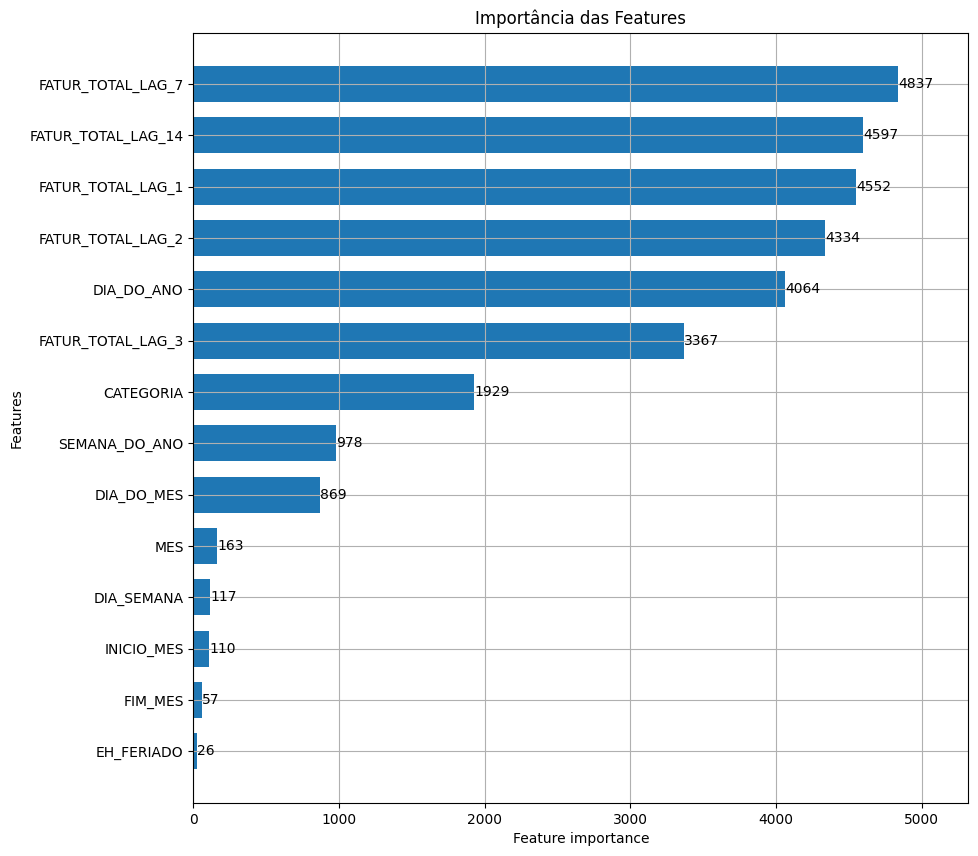

In [29]:
print("Plotando a importância das features...")

# Plotar a importância das features
lgb.plot_importance(model, figsize=(10, 10), max_num_features=25, height=0.7)
plt.title("Importância das Features")
plt.show()

### **7. Análise de Erros por Categoria**

Visão Geral: As métricas globais (RMSE/MAE) nos dão a média, mas não mostram onde o modelo está errando. Esta etapa agrupa os erros por CATEGORIA e calcula o MAE para cada uma. Isso nos permite identificar quais categorias (ex: 'Bacalhau & Pescados') são mais difíceis de prever e quais o modelo já domina.

In [30]:
print("Analisando performance por Categoria...")

# Junta as previsões de volta ao df_val original
df_val_results = df_val.copy()
df_val_results['Previsto'] = y_pred
df_val_results['Erro_Absoluto'] = (df_val_results['Previsto'] - df_val_results[TARGET]).abs()

# Calcula o MAE por Categoria
mae_por_categoria = df_val_results.groupby('CATEGORIA')['Erro_Absoluto'].mean().sort_values(ascending=False)

# Calcula o Faturamento Médio Real (para contexto)
fatur_medio_real = df_val_results.groupby('CATEGORIA')[TARGET].mean()

# Junta os resultados
df_error_analysis = pd.DataFrame({
    'MAE (R$)': mae_por_categoria,
    'Faturamento_Medio_Real (R$)': fatur_medio_real
})

# Calcula o Erro Percentual (MAE / Faturamento Médio)
df_error_analysis['MAE_Percentual'] = (df_error_analysis['MAE (R$)'] / df_error_analysis['Faturamento_Medio_Real (R$)']) * 100

print("\n--- Análise de Erro por Categoria (Ordenado por MAE em R$) ---")
print(df_error_analysis.sort_values(by='MAE (R$)', ascending=False).to_string(float_format='%.2f'))

Analisando performance por Categoria...

--- Análise de Erro por Categoria (Ordenado por MAE em R$) ---
                              MAE (R$)  Faturamento_Medio_Real (R$)  MAE_Percentual
CATEGORIA                                                                          
Bacalhau & Pescados           15238.62                     29816.11           51.11
Castanhas & Oleaginosas        3261.97                      6419.79           50.81
Frutas                         1277.18                      4354.80           29.33
Temperos & Condimentos          457.21                      2406.85           19.00
Conservas                       405.85                       784.23           51.75
Grãos                           249.03                       763.48           32.62
Mixes da Casa                   242.36                      1178.20           20.57
Superalimentos & Energéticos    222.85                       623.38           35.75
Aperitivos                      159.89                  